# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

### Modeling question
This notebook asks whether observable content and search signals can improve the prioritization of pages that are currently labelled as declining. The practical use is **decision-support**: rank pages for human review, not claim that refreshing a page will cause recovery.

### Method choice
I compare three supervised classification models:

- **Logistic Regression** — a simple, interpretable linear benchmark.
- **Decision Tree** — can capture nonlinear rules and interactions while remaining easy to inspect.
- **Random Forest** — combines many trees and is a stronger candidate for structured tabular data when relationships are nonlinear.

The primary comparison is against my **Week-4 transparent baseline score** on the same held-out clients and the same test rows.

I keep the model honest by excluding:
- `content_id` and `client_id` as model features;
- `trend_direction` and `trend_pct`, because the current proxy label is derived from `trend_direction`;
- the Week-4 baseline score and reason codes, because they are outputs of the baseline rather than independent observed features.

The label used here is the starter proxy label `is_declining_label`. This is not a future outcome, so the result should be interpreted as performance on this proxy-label task rather than proof that the model predicts future refresh success.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import pandas as pd

baseline_df = pd.read_csv(
    "/content/drive/MyDrive/flyrank-ml-internship-starter/outputs/baseline_action_score.csv"
)


print("Shape:", baseline_df.shape)

print("\nColumns:")
print(baseline_df.columns.tolist())

baseline_df.head()

Shape: (30000, 49)

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'visibility_score', 'staleness_score', 'baseline_score', 'reason_code', 'action']


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,visibility_score,staleness_score,baseline_score,reason_code,action
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,0.0,good,striking,down,-41.4,0.007346,0.053619,0.000394,high_visibility_page,MONITOR
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.0,good,page_3_5,down,-57.7,0.029592,0.067024,0.001983,high_visibility_page,MONITOR
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.0,good,page_3_5,down,-60.9,0.024301,0.053619,0.001303,high_visibility_page,MONITOR
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,0.0,good,page_1,stable,-13.8,0.022698,0.058981,0.001339,high_visibility_page,MONITOR
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.0,good,page_3_5,down,-34.7,0.036970,0.037534,0.001388,high_visibility_page,MONITOR


In [21]:
!pip install reportlab
%cd /content/flyrank-ml-internship-starter

!python scripts/run_all.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.8 MB/s eta 0:00:00
/content/flyrank-ml-internship-starter

▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, c

In [22]:
# Setup, imports, and data loading

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")


def find_project_root():
    """Find the repo root in Jupyter or Colab without hard-coding a username/path."""
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents, Path("/content")]

    # Common Colab case: the repo is one directory below /content.
    content_dir = Path("/content")
    if content_dir.exists():
        candidates.extend([p for p in content_dir.iterdir() if p.is_dir()])

    for candidate in candidates:
        if (
            (candidate / "data" / "processed" / "refresh_feature_vector.csv").exists()
            and (candidate / "data" / "processed" / "baseline_refresh_queue.csv").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not find the ML-07 processed files. Run the earlier pipeline first: "
        "`python scripts/run_all.py`, then run this notebook from the same repo."
    )


PROJECT_ROOT = find_project_root()
FEATURE_PATH = PROJECT_ROOT / "data/processed/refresh_feature_vector.csv"
BASELINE_PATH = PROJECT_ROOT / "data/processed/baseline_refresh_queue.csv"

features = pd.read_csv(FEATURE_PATH)
baseline = pd.read_csv(BASELINE_PATH)

print("Project root:", PROJECT_ROOT)
print("Feature data shape:", features.shape)
print("Baseline queue shape:", baseline.shape)
print("\nFeature columns:")
print(features.columns.tolist())

Project root: /content/flyrank-ml-internship-starter
Feature data shape: (30000, 52)
Baseline queue shape: (30000, 22)

Feature columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'is_declining_label', 'log_impressions_90d', 'log_clicks_90d', 'log_sessions_90d', 'log_ai_s

## 2. Split design

I use a **client-group holdout split**. Pages belonging to the same client can share content strategy, search patterns, and other client-specific structure. A random row split could therefore place very similar pages from one client in both training and testing, making the evaluation too easy.

Instead, approximately 20% of clients are held out completely for testing. No client appears in both sets. The Week-4 baseline and every model are evaluated on these exact same held-out rows.

Because this notebook uses the starter proxy label rather than a future-window outcome, a time split is not the primary validation design here. A stronger future capstone should use a time-aware feature window and future target window.


In [23]:
# Build the modeling table and create a client-group holdout split

TARGET = "is_declining_label"
GROUP = "client_id"
ID_COLUMNS = ["content_id", "client_id"]

# Find the exact Week-4 baseline score column.
score_candidates = [
    "baseline_refresh_score",
    "baseline_score",
]
baseline_score_col = next(
    (c for c in score_candidates if c in baseline.columns),
    None
)

if baseline_score_col is None:
    matching = [
        c for c in baseline.columns
        if "baseline" in c.lower() and "score" in c.lower()
    ]
    if matching:
        baseline_score_col = matching[0]
    else:
        raise KeyError(
            "No baseline score column was found in baseline_refresh_queue.csv. "
            "Inspect the file and set `baseline_score_col` to the ML-07 score column."
        )

if TARGET not in features.columns:
    raise KeyError(f"Expected target `{TARGET}` in refresh_feature_vector.csv")

if GROUP not in features.columns:
    raise KeyError(f"Expected grouping column `{GROUP}` in refresh_feature_vector.csv")

if "content_id" not in baseline.columns:
    raise KeyError("baseline_refresh_queue.csv must contain content_id for alignment.")

baseline_for_merge = (
    baseline[["content_id", baseline_score_col]]
    .drop_duplicates(subset="content_id")
)

df = features.merge(
    baseline_for_merge,
    on="content_id",
    how="inner",
    validate="one_to_one",
)

# Make the label explicitly binary in case it is stored as True/False.
df[TARGET] = df[TARGET].astype(int)

print("Rows after aligning features with the Week-4 baseline:", len(df))
print("Positive label rate:", f"{df[TARGET].mean():.3f}")
print("Number of clients:", df[GROUP].nunique())

# These fields must never become ordinary model features.
LEAKAGE_COLUMNS = [
    TARGET,
    "trend_direction",
    "trend_pct",
    baseline_score_col,
    "reason_codes",
    "baseline_reason_codes",
    "final_refresh_score",
    "final_reason_codes",
]

# Explicit feature families from the starter data contract.
numeric_candidates = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "age_tier_order",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
]

categorical_candidates = [
    "competition_level",
    "content_type",
    "main_intent",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "char_count_tier",
    "impression_tier",
    "position_tier",
]

numeric_features = [c for c in numeric_candidates if c in df.columns]
categorical_features = [c for c in categorical_candidates if c in df.columns]

# Final safety check: no target-derived or baseline output should be in X.
model_features = numeric_features + categorical_features
for col in ID_COLUMNS + LEAKAGE_COLUMNS:
    if col in model_features:
        model_features.remove(col)

assert TARGET not in model_features
assert "trend_direction" not in model_features
assert "trend_pct" not in model_features
assert baseline_score_col not in model_features

X = df[model_features].copy()
y = df[TARGET].copy()
groups = df[GROUP].copy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

test_rows = df.iloc[test_idx].copy()

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print("\nSplit summary")
print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))
print("Train positive rate:", f"{y_train.mean():.3f}")
print("Test positive rate:", f"{y_test.mean():.3f}")
print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)


Rows after aligning features with the Week-4 baseline: 30000
Positive label rate: 0.542
Number of clients: 32

Split summary
Train rows: 23837
Test rows: 6163
Train clients: 25
Test clients: 7
Client overlap: 0
Train positive rate: 0.550
Test positive rate: 0.511

Numeric features: ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier_order', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']
Categorical features: ['competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'impression_tier', 'position_tier']


## 3. Train + compare vs my baseline

All methods below are evaluated on the **same client-held-out test set**. This makes the comparison fair.

The baseline is not retrained or changed here; its Week-4 score is simply applied to the held-out rows. The three learned models use only the approved observable feature columns listed above.

For this ranked review task:

- **Precision@50** is the primary metric because it asks how many truly positive pages are present among the first 50 pages a reviewer would inspect.
- **Average Precision** summarizes ranking quality across thresholds.
- **ROC-AUC** is included as a broad discrimination metric.

The model is only worth keeping if the improvement over the transparent baseline is useful, not merely more complex.


In [24]:
# Preprocessing, training, and fair baseline comparison

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
    ),
}


def precision_at_k(y_true, scores, k=50):
    k = min(k, len(y_true))
    if k == 0:
        return np.nan
    order = np.argsort(np.asarray(scores))[::-1][:k]
    return float(np.mean(np.asarray(y_true)[order]))


def evaluate_scores(name, y_true, scores):
    scores = np.asarray(scores)
    return {
        "Method": name,
        "ROC-AUC": roc_auc_score(y_true, scores),
        "Average Precision": average_precision_score(y_true, scores),
        "Precision@50": precision_at_k(y_true, scores, k=50),
    }


results = []
predictions = {}

# Week-4 baseline: same held-out rows, same label, same metrics.
baseline_scores = test_rows[baseline_score_col].to_numpy()
results.append(
    evaluate_scores("Week-4 Baseline", y_test, baseline_scores)
)
predictions["Week-4 Baseline"] = baseline_scores

fitted_models = {}

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipe.fit(X_train, y_train)
    scores = pipe.predict_proba(X_test)[:, 1]

    fitted_models[name] = pipe
    predictions[name] = scores
    results.append(evaluate_scores(name, y_test, scores))

results_df = (
    pd.DataFrame(results)
    .sort_values("Precision@50", ascending=False)
    .reset_index(drop=True)
)

display(
    results_df.style.format(
        {
            "ROC-AUC": "{:.3f}",
            "Average Precision": "{:.3f}",
            "Precision@50": "{:.3f}",
        }
    )
)

best_model_name = results_df.iloc[0]["Method"]
print("\nBest method by Precision@50:", best_model_name)

# Compare the strongest learned model with the baseline directly.
learned_only = results_df[results_df["Method"] != "Week-4 Baseline"]
best_learned_name = learned_only.iloc[0]["Method"]

baseline_row = results_df[results_df["Method"] == "Week-4 Baseline"].iloc[0]
best_learned_row = learned_only.iloc[0]

comparison = pd.DataFrame(
    {
        "Metric": ["ROC-AUC", "Average Precision", "Precision@50"],
        "Week-4 Baseline": [
            baseline_row["ROC-AUC"],
            baseline_row["Average Precision"],
            baseline_row["Precision@50"],
        ],
        best_learned_name: [
            best_learned_row["ROC-AUC"],
            best_learned_row["Average Precision"],
            best_learned_row["Precision@50"],
        ],
    }
)

display(comparison.style.format({
    "Week-4 Baseline": "{:.3f}",
    best_learned_name: "{:.3f}",
}))

,Method,ROC-AUC,Average Precision,Precision@50
0,Logistic Regression,0.848,0.866,1.000
1,Decision Tree,0.876,0.859,1.000
2,Random Forest,0.844,0.854,0.980
3,Week-4 Baseline,0.498,0.482,0.320



Best method by Precision@50: Logistic Regression


,Metric,Week-4 Baseline,Logistic Regression
0,ROC-AUC,0.498,0.848
1,Average Precision,0.482,0.866
2,Precision@50,0.320,1.000


## 4. Errors and interpretation

I inspect two things rather than relying only on the metric table:

1. **Where the best learned model makes mistakes** — false positives are pages the model ranked as declining but the proxy label marked negative; false negatives are labelled declining pages the model missed.
2. **What the model leans on** — feature importance is descriptive of model behavior, not evidence that a feature causes decline.

For the error examples, only pseudonymized `content_id` values and aggregate-safe metrics are shown. The interpretation remains decision-support: a high score means “review earlier,” not “this page will definitely decline” or “a refresh will definitely fix it.”

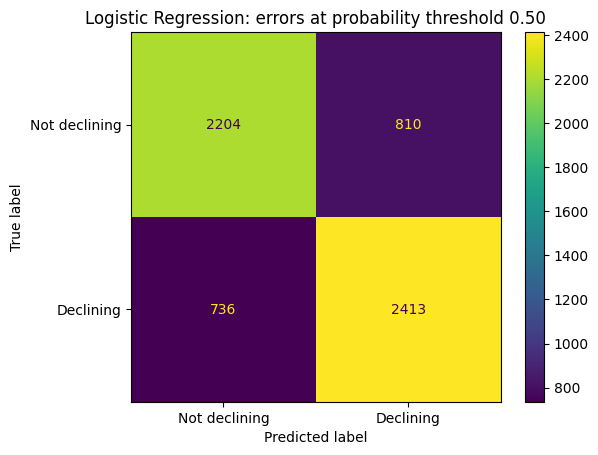

,Metric,Value
0,Precision,0.749
1,Recall,0.766
2,Predicted positives,3223.000
3,Actual positives,3149.000


False positives: 810


,content_id,actual_label,model_probability,baseline_score,predicted_label_0_50,impressions_90d,clicks_90d,sessions_90d,content_age_days,days_since_last_update,avg_position,ctr,engagement_rate,scroll_rate
12869,content_5d5653c4eb4f,0,0.880488,0.591982,1,15101,0,1,421,7,5.7,0.00,0.00,0.00
3488,content_a0777b0fd936,0,0.868434,0.534911,1,13502,3,9,106,8,19.7,0.02,11.11,57.14
11887,content_ce59581533ca,0,0.814217,0.426441,1,289,2,6,223,102,18.8,0.69,0.00,16.67
20736,content_41baf0722ad9,0,0.802668,0.705430,1,3115,0,4,275,104,12.8,0.00,0.00,25.00
7801,content_2dff72da8702,0,0.791855,0.700447,1,2280,8,7,230,104,5.2,0.35,14.29,25.00
8139,content_7fa63804b8f1,0,0.787800,0.809427,1,8258,3,5,300,104,7.3,0.04,0.00,0.00
18531,content_d10f9ce1e0cd,0,0.786272,0.440354,1,166,1,1,348,104,16.1,0.60,0.00,0.00
6739,content_f45787e64ac2,0,0.784598,0.497367,1,291,1,2,347,104,5.2,0.34,0.00,0.00
12332,content_4d9f36001f06,0,0.781827,0.710403,1,3369,1,3,275,104,13.2,0.03,33.33,33.33
6856,content_8f523a52fa57,0,0.780792,0.423440,1,284,1,3,223,54,18.6,0.35,0.00,66.67


False negatives: 736


,content_id,actual_label,model_probability,baseline_score,predicted_label_0_50,impressions_90d,clicks_90d,sessions_90d,content_age_days,days_since_last_update,avg_position,ctr,engagement_rate,scroll_rate
29158,content_e18144cbd19d,1,0.067275,0.147410,0,3,0,1,545,20,2.0,0.0,0.00,0.00
29280,content_ee2303f5bdba,1,0.107461,0.157571,0,4,0,2,348,20,2.5,0.0,0.00,0.00
4081,content_917fc1b11fe1,1,0.126777,0.414453,0,916,0,3,490,22,78.6,0.0,0.00,33.33
4147,content_092f48aa993e,1,0.148658,0.174866,0,13,0,2,502,20,33.2,0.0,0.00,50.00
3179,content_6fc3e66c8c58,1,0.152139,0.185768,0,10,0,1,179,20,2.2,0.0,0.00,0.00
1725,content_8c482a64a3df,1,0.152285,0.112817,0,1,0,15,223,20,3.0,0.0,6.67,20.00
9129,content_3db3c9053d5c,1,0.158761,0.158448,0,4,1,2,126,20,1.3,25.0,0.00,100.00
22907,content_f9563540cd75,1,0.159653,0.146618,0,3,0,5,138,20,1.3,0.0,0.00,20.00
24849,content_2f002563e9cd,1,0.160008,0.203774,0,17,0,37,502,20,5.2,0.0,5.41,7.14
17690,content_c268b1716236,1,0.165068,0.133697,0,3,0,2,502,20,41.7,0.0,0.00,50.00



Interpretation guide:
- Use the metric table to decide whether the learned model earns its complexity.
- Inspect false positives to see where the model may over-prioritize pages.
- Inspect false negatives to see what kinds of declining pages the model misses.
- Treat feature importance as descriptive model behavior, not causal evidence.


In [25]:
# Error analysis and model interpretation

best_model_name = best_learned_name
best_pipe = fitted_models[best_model_name]
best_scores = predictions[best_model_name]
best_labels = (best_scores >= 0.50).astype(int)

# Confusion matrix at a transparent 0.50 probability threshold.
cm = confusion_matrix(y_test, best_labels)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not declining", "Declining"],
)
disp.plot()
plt.title(f"{best_model_name}: errors at probability threshold 0.50")
plt.show()

error_summary = pd.DataFrame(
    {
        "Metric": ["Precision", "Recall", "Predicted positives", "Actual positives"],
        "Value": [
            precision_score(y_test, best_labels, zero_division=0),
            recall_score(y_test, best_labels, zero_division=0),
            int(best_labels.sum()),
            int(y_test.sum()),
        ],
    }
)
display(error_summary.style.format({"Value": "{:.3f}"}))

# Safe error table: pseudonymized content ID + scores + approved observed context.
error_view = test_rows[["content_id"]].copy()
error_view["actual_label"] = y_test.to_numpy()
error_view["model_probability"] = best_scores
error_view["baseline_score"] = baseline_scores
error_view["predicted_label_0_50"] = best_labels

# Add a few safe context columns if present.
context_candidates = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "content_age_days",
    "days_since_last_update",
    "avg_position",
    "ctr",
    "engagement_rate",
    "scroll_rate",
]
for col in context_candidates:
    if col in test_rows.columns:
        error_view[col] = test_rows[col].to_numpy()

false_positives = (
    error_view[
        (error_view["actual_label"] == 0)
        & (error_view["predicted_label_0_50"] == 1)
    ]
    .sort_values("model_probability", ascending=False)
)

false_negatives = (
    error_view[
        (error_view["actual_label"] == 1)
        & (error_view["predicted_label_0_50"] == 0)
    ]
    .sort_values("model_probability", ascending=True)
)

print("False positives:", len(false_positives))
display(false_positives.head(10))

print("False negatives:", len(false_negatives))
display(false_negatives.head(10))

# Random Forest feature importance is directly available after preprocessing.
if best_model_name == "Random Forest":
    fitted_preprocessor = best_pipe.named_steps["preprocessor"]
    feature_names = fitted_preprocessor.get_feature_names_out()
    importances = best_pipe.named_steps["model"].feature_importances_

    importance_df = (
        pd.DataFrame(
            {
                "feature": feature_names,
                "importance": importances,
            }
        )
        .sort_values("importance", ascending=False)
        .head(15)
    )

    display(importance_df)

    plt.figure(figsize=(9, 6))
    plt.barh(
        importance_df["feature"].iloc[::-1],
        importance_df["importance"].iloc[::-1],
    )
    plt.xlabel("Random Forest feature importance")
    plt.title("Top model features (descriptive, not causal)")
    plt.tight_layout()
    plt.show()

print("\nInterpretation guide:")
print(
    "- Use the metric table to decide whether the learned model earns its complexity.\n"
    "- Inspect false positives to see where the model may over-prioritize pages.\n"
    "- Inspect false negatives to see what kinds of declining pages the model misses.\n"
    "- Treat feature importance as descriptive model behavior, not causal evidence."
)

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.